In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re

In [3]:
jobs = pd.read_csv(r"C:\Users\cbala\OneDrive\Desktop\RecruitSmart\data\jobs_cleaned.csv")

jobs.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,clean_description,clean_requirements
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0,food52 a fastgrowing james beard awardwinning ...,experience with content management systems a m...
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,organised focused vibrant awesomedo you have a...,what we expect from youyour key responsibility...
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0,our client located in houston is actively seek...,implement precommissioning and commissioning p...
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,the company esri environmental systems researc...,education bachelors or masters in gis business...
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,job title itemization review managerlocation f...,qualificationsrn license in the state of texas...


In [5]:
jobs["text"] = (
    jobs["description"].fillna("") + " " +
    jobs["requirements"].fillna("")
)

In [7]:
text = " ".join(jobs["text"])

text = text.lower()

text = re.sub(r"[^a-zA-Z ]", "", text)

In [9]:
words = text.split()

In [11]:
stop_words = {
    "the","and","to","of","a","in","for","is",
    "on","with","you","our","we","your","be",
    "will","are","as","or","an","by","this",
    "that","from","at","it","have","has"
}

filtered_words = [
    word
    for word in words
    if word not in stop_words
]

In [13]:
word_counts = Counter(filtered_words)

top20 = word_counts.most_common(20)

top20

[('experience', 28756),
 ('work', 23477),
 ('team', 21253),
 ('all', 14979),
 ('skills', 14887),
 ('business', 14180),
 ('customer', 12695),
 ('sales', 12345),
 ('new', 12039),
 ('development', 11833),
 ('management', 11707),
 ('years', 10818),
 ('working', 9996),
 ('looking', 9697),
 ('company', 9652),
 ('design', 9339),
 ('service', 9183),
 ('amp', 9148),
 ('ability', 9129),
 ('marketing', 9069)]

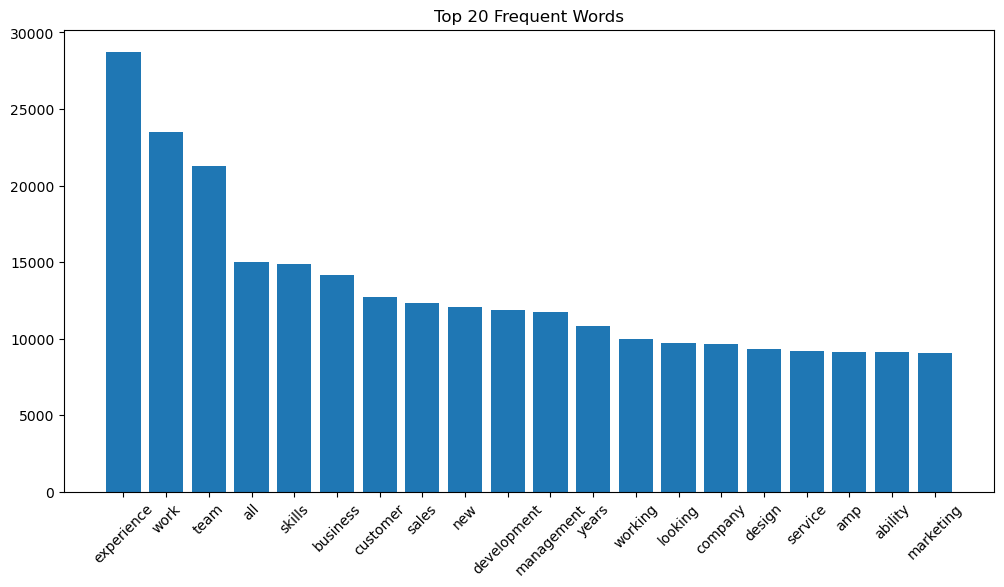

In [15]:
words = [x[0] for x in top20]

counts = [x[1] for x in top20]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Top 20 Frequent Words")

plt.show()

In [17]:
jobs["salary_range"].head(20)

0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
5               NaN
6       20000-28000
7               NaN
8               NaN
9               NaN
10    100000-120000
11              NaN
12              NaN
13              NaN
14              NaN
15    120000-150000
16              NaN
17              NaN
18              NaN
19              NaN
Name: salary_range, dtype: object

In [19]:
salary_jobs = jobs.dropna(subset=["salary_range"]).copy()

salary_jobs.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,...,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,clean_description,clean_requirements,text
6,7,Head of Content (m/f),"DE, BE, Berlin",ANDROIDPIT,20000-28000,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Benefits: Being part of a fast-growing co...,0,...,1,Full-time,Mid-Senior level,Master's Degree,Online Media,Management,0,your responsibilities manage the englishspeaki...,your knowhow university or college degree in j...,Your Responsibilities: Manage the English-spea...
10,11,ASP.net Developer Job opportunity at United St...,"US, NJ, Jersey City",NaN,100000-120000,NaN,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,Benefits - FullBonus Eligible - YesInterview T...,0,...,0,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,0,position url86fd830a95a64e2b30ceed829e63fd384c...,position url86fd830a95a64e2b30ceed829e63fd384c...,Position : #URL_86fd830a95a64e2b30ceed829e63fd...
15,16,VP of Sales - Vault Dragon,"SG, 01, Singapore",Sales,120000-150000,Jungle Ventures is the leading Singapore based...,About Vault Dragon Vault Dragon is Dropbox for...,Key Superpowers3-5 years of high-pressure sale...,"Basic: SGD 120,000Equity negotiable for a rock...",0,...,1,Full-time,Executive,Bachelor's Degree,Facilities Services,Sales,0,about vault dragon vault dragon is dropbox for...,key superpowers35 years of highpressure sales ...,About Vault Dragon Vault Dragon is Dropbox for...
23,24,"Vice President, Sales and Sponsorship (Busines...","US, CA, Carlsbad",Businessfriend.com,100000-120000,"WDM Group is an innovative, forward thinking d...",#URL_eda2500ddcedb60957fcd7f5b164e092966f8c4e8...,"Job Requirements:A reputation as a ""go-getter""...",Businessfriend will offer a competitive six fi...,0,...,0,Full-time,Executive,Unspecified,Internet,Sales,0,urleda2500ddcedb60957fcd7f5b164e092966f8c4e8fb...,job requirementsa reputation as a gogetter and...,#URL_eda2500ddcedb60957fcd7f5b164e092966f8c4e8...
31,32,Software Applications Specialist,"US, KS,",NaN,50000-65000,NaN,"Day to Day-Install, upgrade and configure web-...",Must Have's3+ years of experience with web-bas...,"Medical, Dental, Vision, Life, Disability, Pre...",0,...,0,Full-time,Associate,Unspecified,Computer Software,Engineering,0,day to dayinstall upgrade and configure webbas...,must haves3 years of experience with webbased ...,"Day to Day-Install, upgrade and configure web-..."


In [21]:
def average_salary(salary):
    try:
        low, high = salary.split("-")
        return (int(low) + int(high)) / 2
    except:
        return None

salary_jobs["average_salary"] = salary_jobs["salary_range"].apply(average_salary)

salary_jobs.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,...,employment_type,required_experience,required_education,industry,function,fraudulent,clean_description,clean_requirements,text,average_salary
6,7,Head of Content (m/f),"DE, BE, Berlin",ANDROIDPIT,20000-28000,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Benefits: Being part of a fast-growing co...,0,...,Full-time,Mid-Senior level,Master's Degree,Online Media,Management,0,your responsibilities manage the englishspeaki...,your knowhow university or college degree in j...,Your Responsibilities: Manage the English-spea...,24000.0
10,11,ASP.net Developer Job opportunity at United St...,"US, NJ, Jersey City",NaN,100000-120000,NaN,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,Benefits - FullBonus Eligible - YesInterview T...,0,...,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,0,position url86fd830a95a64e2b30ceed829e63fd384c...,position url86fd830a95a64e2b30ceed829e63fd384c...,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,110000.0
15,16,VP of Sales - Vault Dragon,"SG, 01, Singapore",Sales,120000-150000,Jungle Ventures is the leading Singapore based...,About Vault Dragon Vault Dragon is Dropbox for...,Key Superpowers3-5 years of high-pressure sale...,"Basic: SGD 120,000Equity negotiable for a rock...",0,...,Full-time,Executive,Bachelor's Degree,Facilities Services,Sales,0,about vault dragon vault dragon is dropbox for...,key superpowers35 years of highpressure sales ...,About Vault Dragon Vault Dragon is Dropbox for...,135000.0
23,24,"Vice President, Sales and Sponsorship (Busines...","US, CA, Carlsbad",Businessfriend.com,100000-120000,"WDM Group is an innovative, forward thinking d...",#URL_eda2500ddcedb60957fcd7f5b164e092966f8c4e8...,"Job Requirements:A reputation as a ""go-getter""...",Businessfriend will offer a competitive six fi...,0,...,Full-time,Executive,Unspecified,Internet,Sales,0,urleda2500ddcedb60957fcd7f5b164e092966f8c4e8fb...,job requirementsa reputation as a gogetter and...,#URL_eda2500ddcedb60957fcd7f5b164e092966f8c4e8...,110000.0
31,32,Software Applications Specialist,"US, KS,",NaN,50000-65000,NaN,"Day to Day-Install, upgrade and configure web-...",Must Have's3+ years of experience with web-bas...,"Medical, Dental, Vision, Life, Disability, Pre...",0,...,Full-time,Associate,Unspecified,Computer Software,Engineering,0,day to dayinstall upgrade and configure webbas...,must haves3 years of experience with webbased ...,"Day to Day-Install, upgrade and configure web-...",57500.0


In [23]:
salary_jobs["python_job"] = salary_jobs["requirements"].str.contains(
    "Python",
    case=False,
    na=False
)

salary_jobs.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,...,required_experience,required_education,industry,function,fraudulent,clean_description,clean_requirements,text,average_salary,python_job
6,7,Head of Content (m/f),"DE, BE, Berlin",ANDROIDPIT,20000-28000,"Founded in 2009, the Fonpit AG rose with its i...",Your Responsibilities: Manage the English-spea...,Your Know-How: ...,Your Benefits: Being part of a fast-growing co...,0,...,Mid-Senior level,Master's Degree,Online Media,Management,0,your responsibilities manage the englishspeaki...,your knowhow university or college degree in j...,Your Responsibilities: Manage the English-spea...,24000.0,False
10,11,ASP.net Developer Job opportunity at United St...,"US, NJ, Jersey City",NaN,100000-120000,NaN,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,Benefits - FullBonus Eligible - YesInterview T...,0,...,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology,0,position url86fd830a95a64e2b30ceed829e63fd384c...,position url86fd830a95a64e2b30ceed829e63fd384c...,Position : #URL_86fd830a95a64e2b30ceed829e63fd...,110000.0,False
15,16,VP of Sales - Vault Dragon,"SG, 01, Singapore",Sales,120000-150000,Jungle Ventures is the leading Singapore based...,About Vault Dragon Vault Dragon is Dropbox for...,Key Superpowers3-5 years of high-pressure sale...,"Basic: SGD 120,000Equity negotiable for a rock...",0,...,Executive,Bachelor's Degree,Facilities Services,Sales,0,about vault dragon vault dragon is dropbox for...,key superpowers35 years of highpressure sales ...,About Vault Dragon Vault Dragon is Dropbox for...,135000.0,False
23,24,"Vice President, Sales and Sponsorship (Busines...","US, CA, Carlsbad",Businessfriend.com,100000-120000,"WDM Group is an innovative, forward thinking d...",#URL_eda2500ddcedb60957fcd7f5b164e092966f8c4e8...,"Job Requirements:A reputation as a ""go-getter""...",Businessfriend will offer a competitive six fi...,0,...,Executive,Unspecified,Internet,Sales,0,urleda2500ddcedb60957fcd7f5b164e092966f8c4e8fb...,job requirementsa reputation as a gogetter and...,#URL_eda2500ddcedb60957fcd7f5b164e092966f8c4e8...,110000.0,False
31,32,Software Applications Specialist,"US, KS,",NaN,50000-65000,NaN,"Day to Day-Install, upgrade and configure web-...",Must Have's3+ years of experience with web-bas...,"Medical, Dental, Vision, Life, Disability, Pre...",0,...,Associate,Unspecified,Computer Software,Engineering,0,day to dayinstall upgrade and configure webbas...,must haves3 years of experience with webbased ...,"Day to Day-Install, upgrade and configure web-...",57500.0,False


In [25]:
salary_summary = salary_jobs.groupby("python_job")["average_salary"].mean()

print(salary_summary)

python_job
False    681604.276968
True     168178.556701
Name: average_salary, dtype: float64


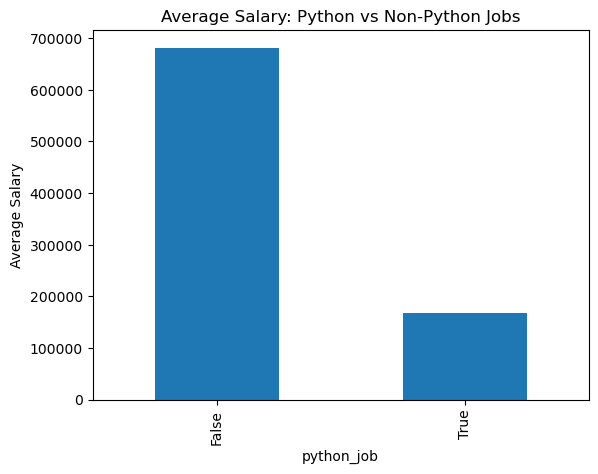

In [27]:
import matplotlib.pyplot as plt

salary_summary.plot(kind="bar")

plt.title("Average Salary: Python vs Non-Python Jobs")
plt.ylabel("Average Salary")

plt.show()

In [29]:
feature_matrix = pd.read_csv("flattened_feature_matrix.csv")

In [31]:
feature_matrix["match_relevance_score"].value_counts()

match_relevance_score
0.9    513
0.5    376
0.2    111
Name: count, dtype: int64